# 03 — Exploratory Data Analysis

Explore demand, revenue, trip efficiency, payment behavior, and location patterns.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", "{:,.2f}".format)

## Project Paths

In [2]:
current_path = Path.cwd()

if current_path.name == "notebooks":
    project_root = current_path.parent
else:
    project_root = current_path

processed_data_dir = project_root / "data" / "processed"
reports_dir = project_root / "reports"
figures_dir = reports_dir / "figures"

reports_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

cleaned_trip_data_path = processed_data_dir / "cleaned_yellow_taxi_jan_2024.parquet"

print(f"Project root: {project_root}")
print(f"Cleaned data path exists: {cleaned_trip_data_path.exists()}")

Project root: /Users/angelonelson/Projects/NYCTaxiTripAnalytics
Cleaned data path exists: True


## Load Cleaned Dataset

In [3]:
taxi_trips = pd.read_parquet(cleaned_trip_data_path)

print(f"Cleaned taxi trips shape: {taxi_trips.shape[0]:,} rows and {taxi_trips.shape[1]:,} columns")
taxi_trips.head()

Cleaned taxi trips shape: 2,868,035 rows and 47 columns


,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,trip_distance,rate_code_id,store_and_fwd_flag,pickup_location_id,dropoff_location_id,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,trip_duration_minutes,passenger_count_clean,passenger_count_group,vendor_name,rate_code_label,payment_type_label,pickup_date,pickup_year,pickup_month,pickup_day,pickup_hour,pickup_day_name,pickup_day_of_week,is_weekend,revenue_per_mile,fare_per_minute,tip_percentage,distance_bucket,duration_bucket,pickup_borough,pickup_zone,pickup_service_zone,dropoff_borough,dropoff_zone,dropoff_service_zone,is_high_value_trip,is_long_distance_trip,is_long_duration_trip
0,2,2024-01-01 00:57:55,2024-01-01 01:17:43,1.00,1.72,1.00,N,186,79,2,17.70,1.00,0.50,0.00,0.00,1.00,22.70,2.50,0.00,19.80,1,Solo,VeriFone Inc.,Standard rate,Cash,2024-01-01,2024,1,1,0,Monday,0,False,13.20,0.89,0.00,1-3 miles,10-20 min,Manhattan,Penn Station/Madison Sq West,Yellow Zone,Manhattan,East Village,Yellow Zone,False,False,False
1,1,2024-01-01 00:03:00,2024-01-01 00:09:36,1.00,1.80,1.00,N,140,236,1,10.00,3.50,0.50,3.75,0.00,1.00,18.75,2.50,0.00,6.60,1,Solo,Creative Mobile Technologies,Standard rate,Credit card,2024-01-01,2024,1,1,0,Monday,0,False,10.42,1.52,37.50,1-3 miles,5-10 min,Manhattan,Lenox Hill East,Yellow Zone,Manhattan,Upper East Side North,Yellow Zone,False,False,False
2,1,2024-01-01 00:17:06,2024-01-01 00:35:01,1.00,4.70,1.00,N,236,79,1,23.30,3.50,0.50,3.00,0.00,1.00,31.30,2.50,0.00,17.92,1,Solo,Creative Mobile Technologies,Standard rate,Credit card,2024-01-01,2024,1,1,0,Monday,0,False,6.66,1.30,12.88,3-5 miles,10-20 min,Manhattan,Upper East Side North,Yellow Zone,Manhattan,East Village,Yellow Zone,False,False,False
3,1,2024-01-01 00:36:38,2024-01-01 00:44:56,1.00,1.40,1.00,N,79,211,1,10.00,3.50,0.50,2.00,0.00,1.00,17.00,2.50,0.00,8.30,1,Solo,Creative Mobile Technologies,Standard rate,Credit card,2024-01-01,2024,1,1,0,Monday,0,False,12.14,1.20,20.00,1-3 miles,5-10 min,Manhattan,East Village,Yellow Zone,Manhattan,SoHo,Yellow Zone,False,False,False
4,1,2024-01-01 00:46:51,2024-01-01 00:52:57,1.00,0.80,1.00,N,211,148,1,7.90,3.50,0.50,3.20,0.00,1.00,16.10,2.50,0.00,6.10,1,Solo,Creative Mobile Technologies,Standard rate,Credit card,2024-01-01,2024,1,1,0,Monday,0,False,20.12,1.30,40.51,0-1 miles,5-10 min,Manhattan,SoHo,Yellow Zone,Manhattan,Lower East Side,Yellow Zone,False,False,False


## Quick Quality Check

In [4]:
eda_quality_summary = {
    "row_count": len(taxi_trips),
    "column_count": taxi_trips.shape[1],
    "duplicate_rows": taxi_trips.duplicated().sum(),
    "pickup_start": taxi_trips["pickup_datetime"].min(),
    "pickup_end": taxi_trips["pickup_datetime"].max(),
    "missing_values_total": taxi_trips.isna().sum().sum(),
}

eda_quality_summary

{'row_count': 2868035,
 'column_count': 47,
 'duplicate_rows': np.int64(0),
 'pickup_start': Timestamp('2024-01-01 00:00:00'),
 'pickup_end': Timestamp('2024-01-31 23:59:55'),
 'missing_values_total': np.int64(460948)}

## Core KPIs

In [5]:
total_trips = len(taxi_trips)
total_revenue = taxi_trips["total_amount"].sum()
average_total_amount = taxi_trips["total_amount"].mean()
average_fare_amount = taxi_trips["fare_amount"].mean()
average_trip_distance = taxi_trips["trip_distance"].mean()
average_trip_duration = taxi_trips["trip_duration_minutes"].mean()
average_revenue_per_mile = taxi_trips["revenue_per_mile"].replace([np.inf, -np.inf], np.nan).mean()
average_tip_amount = taxi_trips["tip_amount"].mean()
average_tip_percentage = taxi_trips["tip_percentage"].replace([np.inf, -np.inf], np.nan).mean()
credit_card_share = (taxi_trips["payment_type_label"].eq("Credit card").mean()) * 100

kpi_summary = pd.DataFrame({
    "kpi": [
        "Total Trips",
        "Total Revenue",
        "Average Total Amount",
        "Average Fare Amount",
        "Average Trip Distance",
        "Average Trip Duration",
        "Average Revenue per Mile",
        "Average Tip Amount",
        "Average Tip Percentage",
        "Credit Card Payment Share",
    ],
    "value": [
        total_trips,
        total_revenue,
        average_total_amount,
        average_fare_amount,
        average_trip_distance,
        average_trip_duration,
        average_revenue_per_mile,
        average_tip_amount,
        average_tip_percentage,
        credit_card_share,
    ],
})

kpi_summary

,kpi,value
0,Total Trips,"2,868,035.00"
1,Total Revenue,"78,407,817.41"
2,Average Total Amount,27.34
3,Average Fare Amount,18.49
4,Average Trip Distance,3.73
5,Average Trip Duration,14.96
6,Average Revenue per Mile,17.49
7,Average Tip Amount,3.40
8,Average Tip Percentage,21.42
9,Credit Card Payment Share,80.09


In [6]:
kpi_summary.to_csv(processed_data_dir / "eda_kpi_summary.csv", index=False)
print("KPI summary saved.")

KPI summary saved.


## Daily Demand Trend

In [7]:
daily_demand_summary = (
    taxi_trips
    .groupby("pickup_date")
    .agg(
        total_trips=("pickup_datetime", "count"),
        total_revenue=("total_amount", "sum"),
        average_trip_distance=("trip_distance", "mean"),
        average_trip_duration=("trip_duration_minutes", "mean"),
        average_total_amount=("total_amount", "mean"),
    )
    .reset_index()
)

daily_demand_summary.head()

,pickup_date,total_trips,total_revenue,average_trip_distance,average_trip_duration,average_total_amount
0,2024-01-01,75443,"2,335,768.45",4.66,15.10,30.96
1,2024-01-02,72944,"2,251,733.64",4.21,16.02,30.87
2,2024-01-03,79907,"2,337,062.79",3.95,15.82,29.25
3,2024-01-04,100089,"2,778,329.17",3.36,15.35,27.76
4,2024-01-05,100079,"2,699,790.82",3.83,14.70,26.98


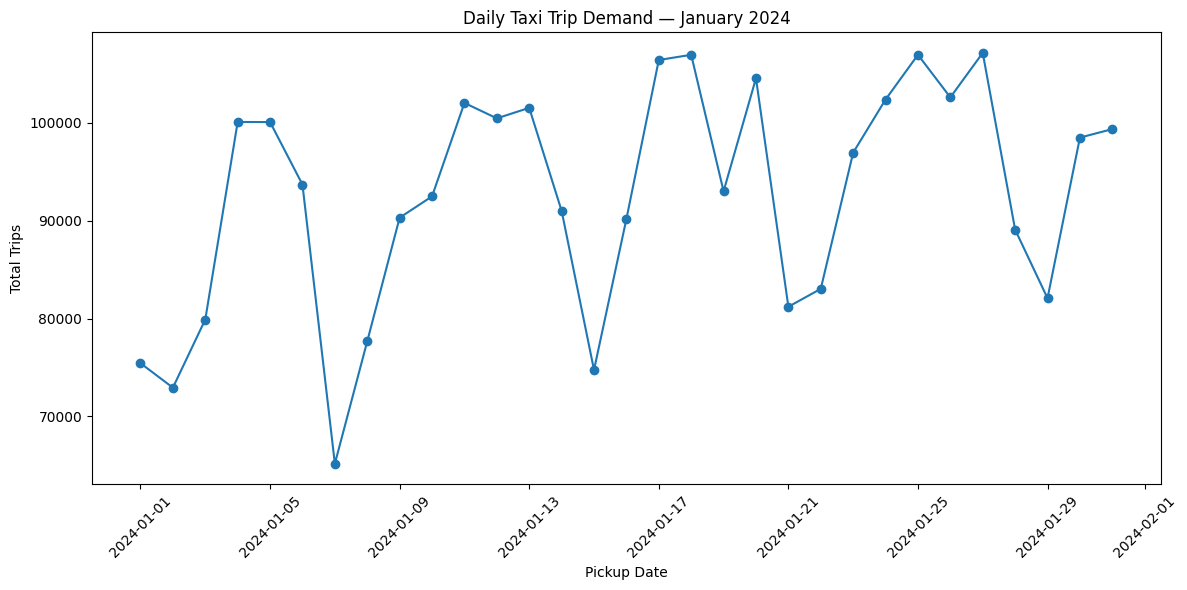

In [8]:
daily_demand_summary.to_csv(processed_data_dir / "daily_demand_summary.csv", index=False)

plt.figure(figsize=(12, 6))
plt.plot(daily_demand_summary["pickup_date"], daily_demand_summary["total_trips"], marker="o")
plt.title("Daily Taxi Trip Demand — January 2024")
plt.xlabel("Pickup Date")
plt.ylabel("Total Trips")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(figures_dir / "daily_taxi_trip_demand.png", dpi=300)
plt.show()

## Hourly Demand

In [9]:
hourly_demand_summary = (
    taxi_trips
    .groupby("pickup_hour")
    .agg(
        total_trips=("pickup_datetime", "count"),
        total_revenue=("total_amount", "sum"),
        average_total_amount=("total_amount", "mean"),
        average_trip_distance=("trip_distance", "mean"),
        average_trip_duration=("trip_duration_minutes", "mean"),
    )
    .reset_index()
)

hourly_demand_summary

,pickup_hour,total_trips,total_revenue,average_total_amount,average_trip_distance,average_trip_duration
0,0,75166,"2,147,600.73",28.57,3.85,13.72
1,1,50437,"1,306,245.28",25.90,3.27,12.69
2,2,34937,"859,245.77",24.59,3.04,12.01
3,3,22923,"612,113.30",26.70,3.52,12.15
4,4,15263,"495,412.98",32.46,4.87,13.99
5,5,17487,"656,879.43",37.56,9.18,16.53
6,6,39393,"1,187,456.41",30.14,13.48,15.74
7,7,80824,"2,143,610.38",26.52,6.18,15.00
8,8,113451,"2,897,223.32",25.54,5.59,15.18
9,9,125541,"3,250,967.79",25.90,3.05,15.12


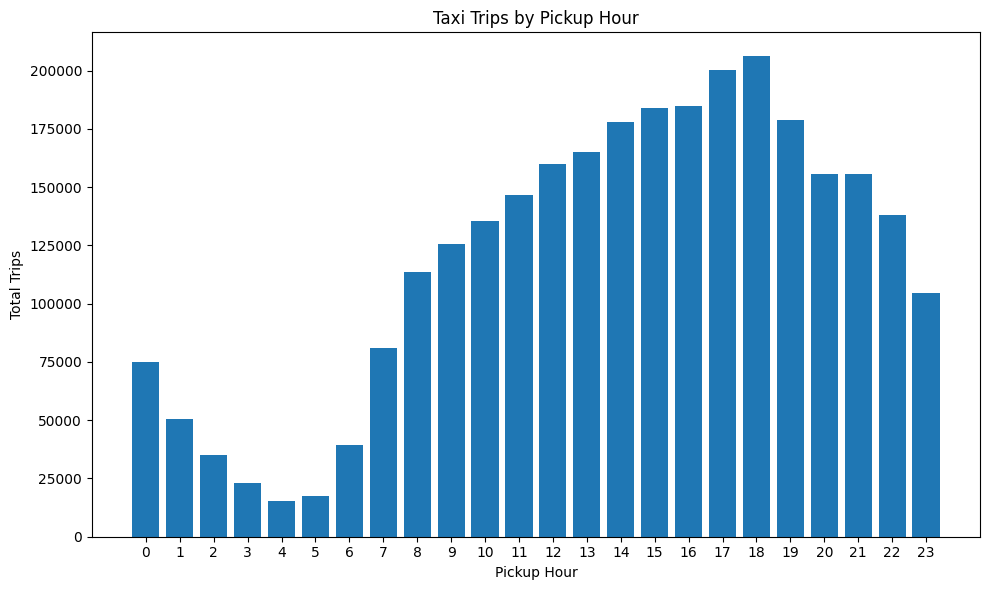

In [10]:
hourly_demand_summary.to_csv(processed_data_dir / "hourly_demand_summary.csv", index=False)

plt.figure(figsize=(10, 6))
plt.bar(hourly_demand_summary["pickup_hour"], hourly_demand_summary["total_trips"])
plt.title("Taxi Trips by Pickup Hour")
plt.xlabel("Pickup Hour")
plt.ylabel("Total Trips")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.savefig(figures_dir / "hourly_taxi_demand.png", dpi=300)
plt.show()

## Day-of-Week Demand

In [11]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

weekday_demand_summary = (
    taxi_trips
    .groupby("pickup_day_name")
    .agg(
        total_trips=("pickup_datetime", "count"),
        total_revenue=("total_amount", "sum"),
        average_total_amount=("total_amount", "mean"),
        average_trip_distance=("trip_distance", "mean"),
        average_trip_duration=("trip_duration_minutes", "mean"),
    )
    .reindex(day_order)
    .reset_index()
)

weekday_demand_summary

,pickup_day_name,total_trips,total_revenue,average_total_amount,average_trip_distance,average_trip_duration
0,Monday,393005,"11,331,302.80",28.83,3.77,14.96
1,Tuesday,448879,"12,404,110.57",27.63,4.24,15.47
2,Wednesday,480554,"13,220,799.18",27.51,3.61,15.52
3,Thursday,416030,"11,532,275.36",27.72,3.54,15.78
4,Friday,396156,"10,767,101.27",27.18,3.67,15.16
5,Saturday,406923,"10,254,988.91",25.20,3.39,13.90
6,Sunday,326488,"8,897,239.32",27.25,3.90,13.43


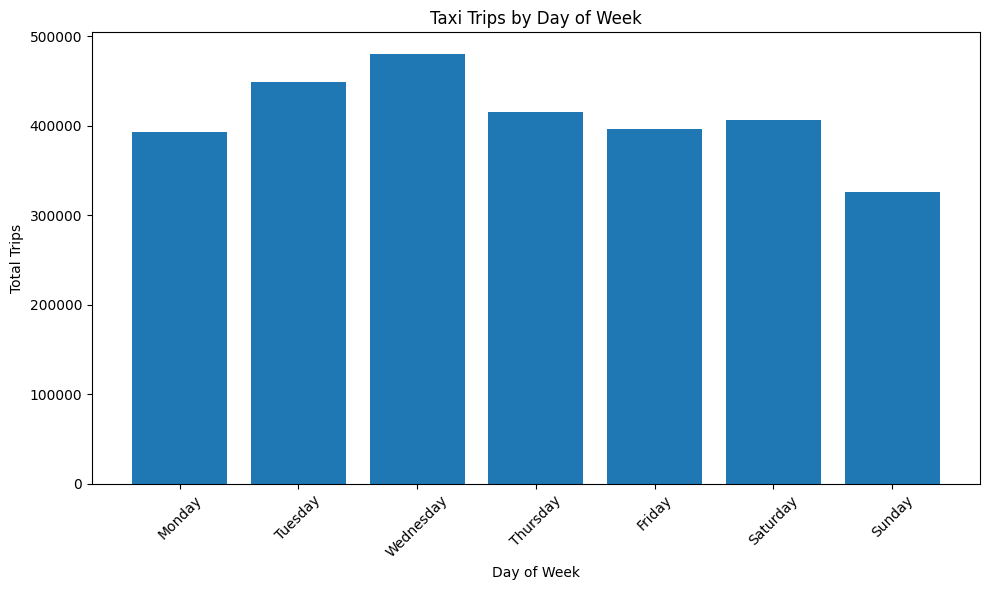

In [12]:
weekday_demand_summary.to_csv(processed_data_dir / "weekday_demand_summary.csv", index=False)

plt.figure(figsize=(10, 6))
plt.bar(weekday_demand_summary["pickup_day_name"], weekday_demand_summary["total_trips"])
plt.title("Taxi Trips by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Total Trips")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(figures_dir / "weekday_taxi_demand.png", dpi=300)
plt.show()

## Revenue by Hour

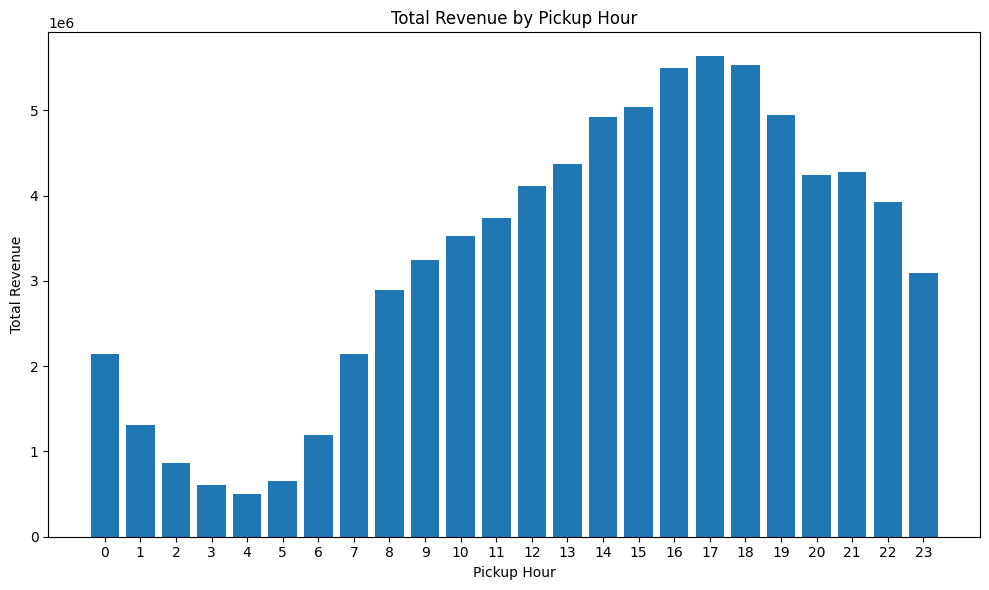

In [13]:
plt.figure(figsize=(10, 6))
plt.bar(hourly_demand_summary["pickup_hour"], hourly_demand_summary["total_revenue"])
plt.title("Total Revenue by Pickup Hour")
plt.xlabel("Pickup Hour")
plt.ylabel("Total Revenue")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.savefig(figures_dir / "hourly_revenue.png", dpi=300)
plt.show()

## Trip Distance Distribution

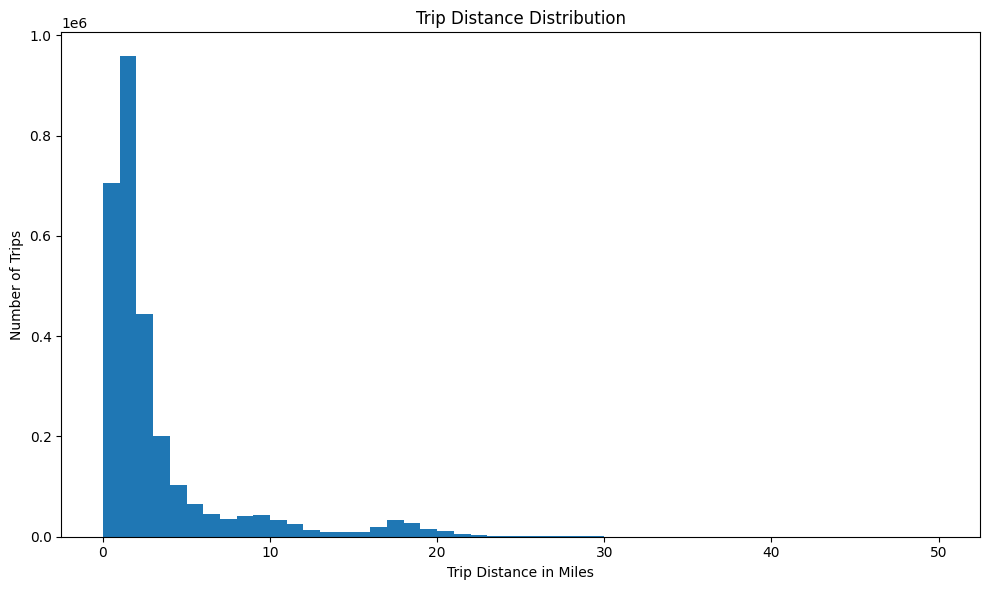

count   2,868,035.00
mean            3.73
std           229.23
min             0.01
25%             1.02
50%             1.70
75%             3.19
max       312,722.30
Name: trip_distance, dtype: float64

In [14]:
trip_distance_for_plot = taxi_trips.loc[taxi_trips["trip_distance"] <= 50, "trip_distance"]

plt.figure(figsize=(10, 6))
plt.hist(trip_distance_for_plot, bins=50)
plt.title("Trip Distance Distribution")
plt.xlabel("Trip Distance in Miles")
plt.ylabel("Number of Trips")
plt.tight_layout()
plt.savefig(figures_dir / "trip_distance_distribution.png", dpi=300)
plt.show()

taxi_trips["trip_distance"].describe()

## Trip Duration Distribution

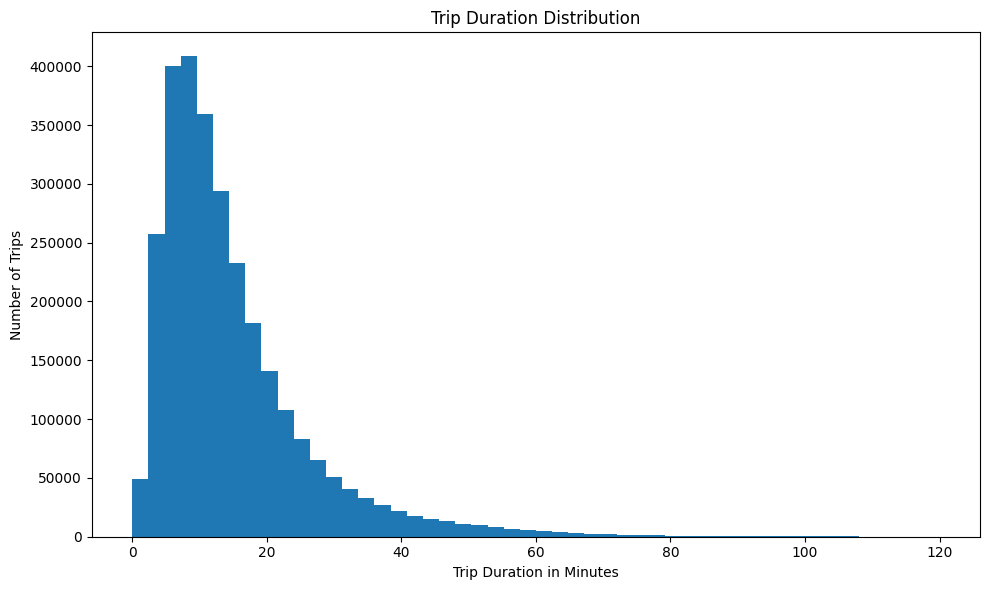

count   2,868,035.00
mean           14.96
std            11.81
min             0.02
25%             7.27
50%            11.72
75%            18.73
max           179.07
Name: trip_duration_minutes, dtype: float64

In [15]:
trip_duration_for_plot = taxi_trips.loc[taxi_trips["trip_duration_minutes"] <= 120, "trip_duration_minutes"]

plt.figure(figsize=(10, 6))
plt.hist(trip_duration_for_plot, bins=50)
plt.title("Trip Duration Distribution")
plt.xlabel("Trip Duration in Minutes")
plt.ylabel("Number of Trips")
plt.tight_layout()
plt.savefig(figures_dir / "trip_duration_distribution.png", dpi=300)
plt.show()

taxi_trips["trip_duration_minutes"].describe()

## Pickup Borough Analysis

In [16]:
pickup_borough_summary = (
    taxi_trips
    .groupby("pickup_borough")
    .agg(
        total_trips=("pickup_datetime", "count"),
        total_revenue=("total_amount", "sum"),
        average_total_amount=("total_amount", "mean"),
        average_trip_distance=("trip_distance", "mean"),
        average_trip_duration=("trip_duration_minutes", "mean"),
        average_revenue_per_mile=("revenue_per_mile", "mean"),
    )
    .sort_values("total_trips", ascending=False)
    .reset_index()
)

pickup_borough_summary

,pickup_borough,total_trips,total_revenue,average_total_amount,average_trip_distance,average_trip_duration,average_revenue_per_mile
0,Manhattan,2572024,"58,534,866.14",22.76,2.72,13.01,17.02
1,Queens,257603,"18,603,571.20",72.22,12.81,32.40,19.28
2,Brooklyn,22254,"738,652.11",33.19,14.82,31.64,22.62
3,Unknown,10316,"319,584.33",30.98,3.73,15.35,66.22
4,Bronx,5742,"203,476.13",35.44,7.73,38.17,15.76
5,EWR,50,"4,860.04",97.20,6.00,7.59,"2,501.20"
6,Staten Island,46,"2,807.46",61.03,9.99,20.18,41.56


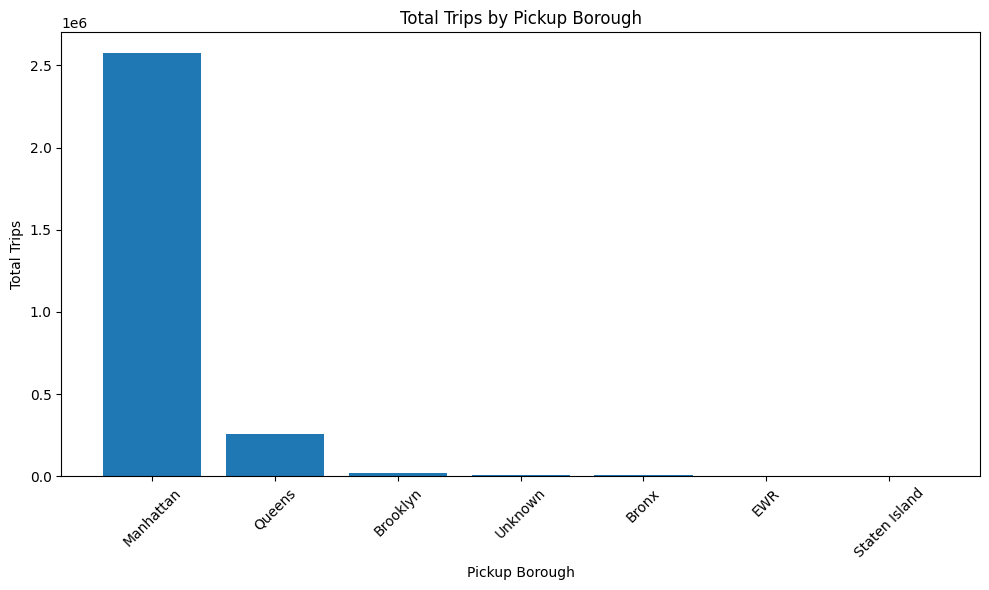

In [17]:
pickup_borough_summary.to_csv(processed_data_dir / "pickup_borough_summary.csv", index=False)

plt.figure(figsize=(10, 6))
plt.bar(pickup_borough_summary["pickup_borough"], pickup_borough_summary["total_trips"])
plt.title("Total Trips by Pickup Borough")
plt.xlabel("Pickup Borough")
plt.ylabel("Total Trips")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(figures_dir / "pickup_borough_trips.png", dpi=300)
plt.show()

## Drop-off Borough Analysis

In [18]:
dropoff_borough_summary = (
    taxi_trips
    .groupby("dropoff_borough")
    .agg(
        total_trips=("pickup_datetime", "count"),
        total_revenue=("total_amount", "sum"),
        average_total_amount=("total_amount", "mean"),
        average_trip_distance=("trip_distance", "mean"),
        average_trip_duration=("trip_duration_minutes", "mean"),
        average_revenue_per_mile=("revenue_per_mile", "mean"),
    )
    .sort_values("total_trips", ascending=False)
    .reset_index()
)

dropoff_borough_summary

,dropoff_borough,total_trips,total_revenue,average_total_amount,average_trip_distance,average_trip_duration,average_revenue_per_mile
0,Manhattan,2583234,"62,203,035.46",24.08,3.03,13.42,16.77
1,Queens,133282,"7,361,113.59",55.23,10.00,27.74,30.79
2,Brooklyn,103001,"5,306,889.69",51.52,9.02,30.59,9.68
3,Unknown,24911,"1,695,553.53",68.06,9.98,23.78,55.70
4,Bronx,16197,"901,182.36",55.64,14.68,32.14,9.48
5,EWR,6804,"870,873.98",127.99,18.44,36.87,25.73
6,Staten Island,606,"69,168.80",114.14,22.03,42.43,9.99


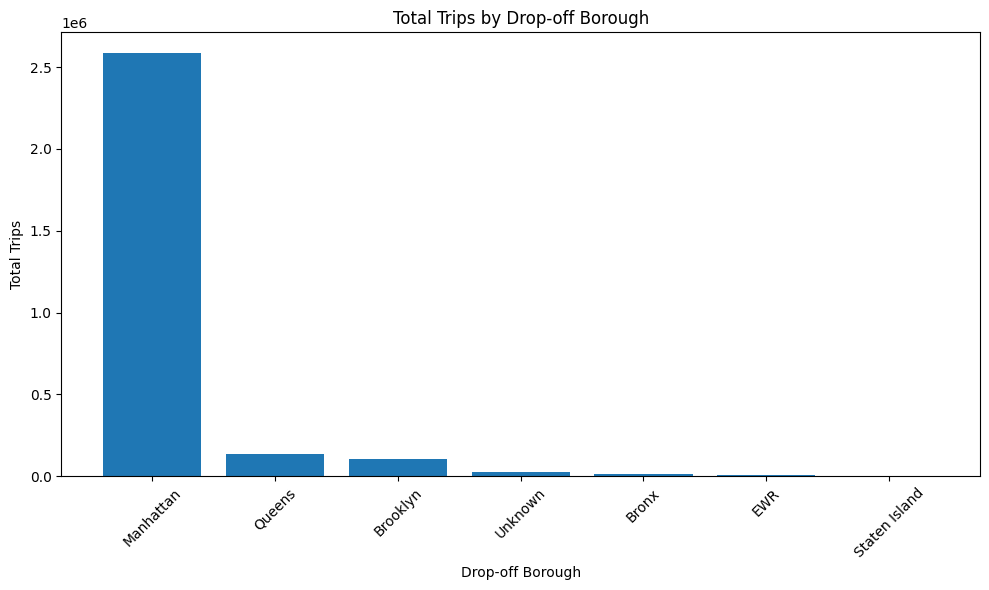

In [19]:
dropoff_borough_summary.to_csv(processed_data_dir / "dropoff_borough_summary.csv", index=False)

plt.figure(figsize=(10, 6))
plt.bar(dropoff_borough_summary["dropoff_borough"], dropoff_borough_summary["total_trips"])
plt.title("Total Trips by Drop-off Borough")
plt.xlabel("Drop-off Borough")
plt.ylabel("Total Trips")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(figures_dir / "dropoff_borough_trips.png", dpi=300)
plt.show()

## Top Pickup Zones

In [20]:
top_pickup_zones = (
    taxi_trips
    .groupby(["pickup_borough", "pickup_zone"])
    .agg(
        total_trips=("pickup_datetime", "count"),
        total_revenue=("total_amount", "sum"),
        average_total_amount=("total_amount", "mean"),
        average_trip_distance=("trip_distance", "mean"),
    )
    .sort_values("total_trips", ascending=False)
    .head(15)
    .reset_index()
)

top_pickup_zones

,pickup_borough,pickup_zone,total_trips,total_revenue,average_total_amount,average_trip_distance
0,Manhattan,Midtown Center,140074,"3,354,213.05",23.95,2.60
1,Manhattan,Upper East Side South,140069,"2,770,461.15",19.78,1.72
2,Queens,JFK Airport,138311,"11,183,307.46",80.86,15.94
3,Manhattan,Upper East Side North,133901,"2,712,549.69",20.26,1.87
4,Manhattan,Midtown East,104298,"2,433,071.91",23.33,2.26
5,Manhattan,Times Sq/Theatre District,102890,"2,763,318.22",26.86,2.97
6,Manhattan,Penn Station/Madison Sq West,102099,"2,461,096.70",24.11,2.30
7,Manhattan,Lincoln Square East,101706,"2,169,364.02",21.33,2.12
8,Queens,LaGuardia Airport,87658,"5,817,091.86",66.36,9.71
9,Manhattan,Upper West Side South,86432,"1,833,747.87",21.22,2.29


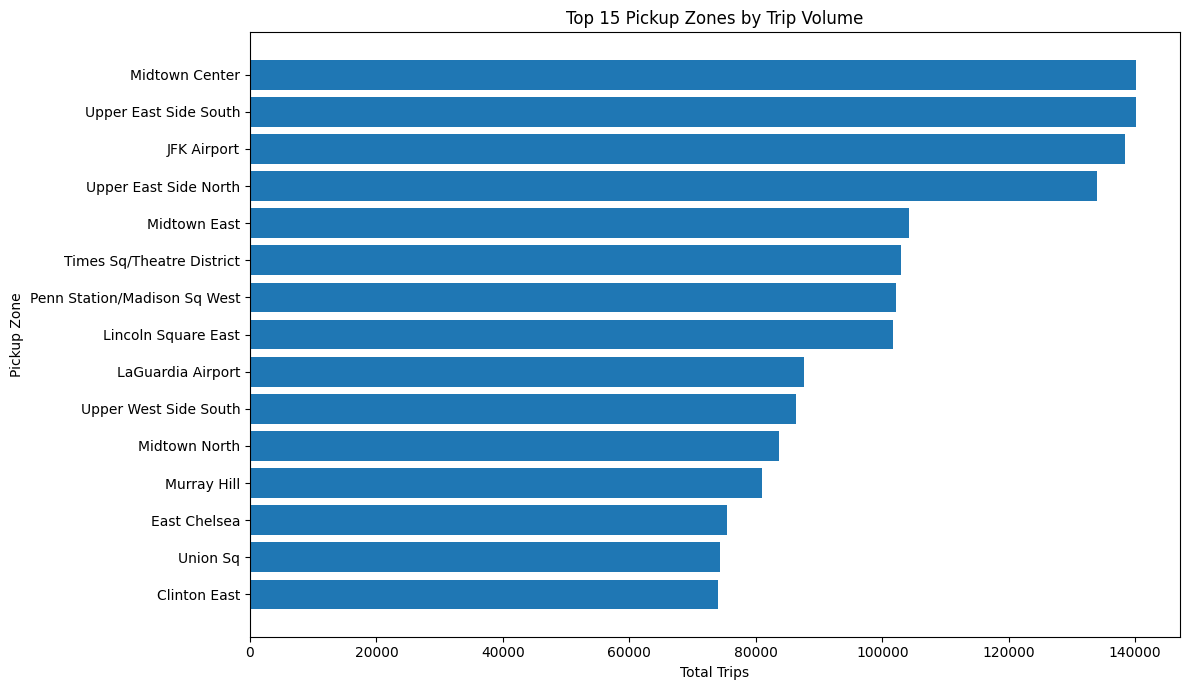

In [21]:
top_pickup_zones.to_csv(processed_data_dir / "top_pickup_zones.csv", index=False)

plt.figure(figsize=(12, 7))
plt.barh(top_pickup_zones["pickup_zone"], top_pickup_zones["total_trips"])
plt.title("Top 15 Pickup Zones by Trip Volume")
plt.xlabel("Total Trips")
plt.ylabel("Pickup Zone")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(figures_dir / "top_pickup_zones.png", dpi=300)
plt.show()

## Payment Type Analysis

In [22]:
payment_type_summary = (
    taxi_trips
    .groupby("payment_type_label")
    .agg(
        total_trips=("pickup_datetime", "count"),
        total_revenue=("total_amount", "sum"),
        average_total_amount=("total_amount", "mean"),
        average_tip_amount=("tip_amount", "mean"),
        average_tip_percentage=("tip_percentage", "mean"),
        average_trip_distance=("trip_distance", "mean"),
    )
    .sort_values("total_trips", ascending=False)
    .reset_index()
)

payment_type_summary["trip_share_percentage"] = (
    payment_type_summary["total_trips"] / payment_type_summary["total_trips"].sum() * 100
).round(2)

payment_type_summary

,payment_type_label,total_trips,total_revenue,average_total_amount,average_tip_amount,average_tip_percentage,average_trip_distance,trip_share_percentage
0,Credit card,2296991,"64,481,551.05",28.07,4.16,26.28,3.29,80.09
1,Cash,422295,"10,064,127.37",23.83,0.00,0.00,3.31,14.72
2,Unknown,115237,"3,054,982.56",26.51,1.84,9.14,14.15,4.02
3,Dispute,22874,"571,757.78",25.00,0.00,0.03,3.43,0.80
4,No charge,10638,"235,398.65",22.13,0.00,0.04,2.86,0.37


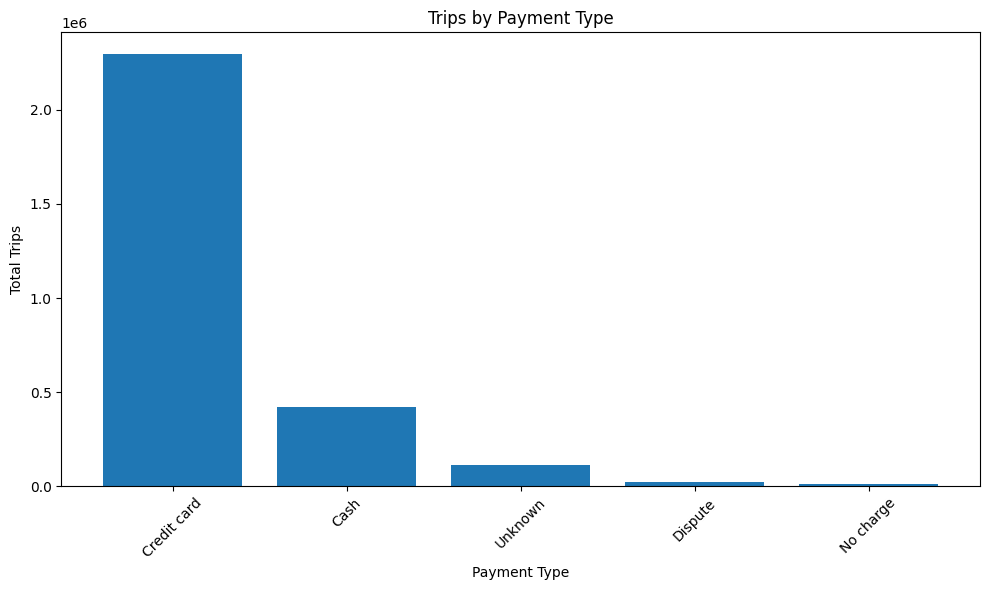

In [23]:
payment_type_summary.to_csv(processed_data_dir / "payment_type_summary.csv", index=False)

plt.figure(figsize=(10, 6))
plt.bar(payment_type_summary["payment_type_label"], payment_type_summary["total_trips"])
plt.title("Trips by Payment Type")
plt.xlabel("Payment Type")
plt.ylabel("Total Trips")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(figures_dir / "payment_type_distribution.png", dpi=300)
plt.show()

## Tip Behavior by Payment Type

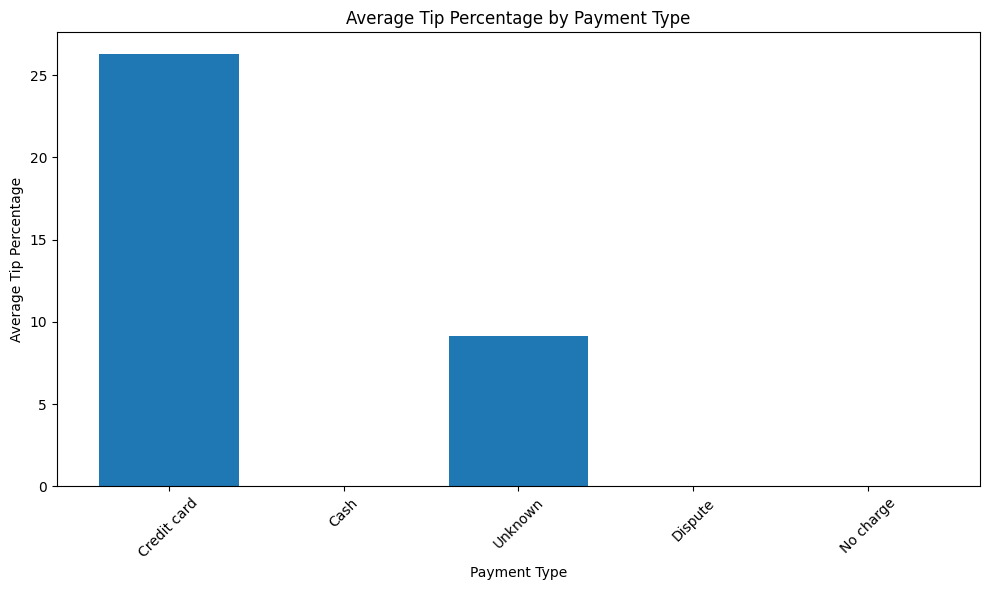

In [24]:
plt.figure(figsize=(10, 6))
plt.bar(payment_type_summary["payment_type_label"], payment_type_summary["average_tip_percentage"])
plt.title("Average Tip Percentage by Payment Type")
plt.xlabel("Payment Type")
plt.ylabel("Average Tip Percentage")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(figures_dir / "tip_percentage_by_payment_type.png", dpi=300)
plt.show()

## Distance Bucket Analysis

In [25]:
distance_bucket_summary = (
    taxi_trips
    .groupby("distance_bucket")
    .agg(
        total_trips=("pickup_datetime", "count"),
        total_revenue=("total_amount", "sum"),
        average_total_amount=("total_amount", "mean"),
        average_trip_duration=("trip_duration_minutes", "mean"),
        average_revenue_per_mile=("revenue_per_mile", "mean"),
    )
    .reset_index()
)

distance_bucket_summary

,distance_bucket,total_trips,total_revenue,average_total_amount,average_trip_duration,average_revenue_per_mile
0,0-1 miles,704747,"10,065,419.80",14.28,5.99,39.75
1,1-3 miles,1402648,"28,646,906.20",20.42,12.30,12.05
2,3-5 miles,305453,"9,437,188.56",30.90,20.63,8.21
3,5-10 miles,230426,"10,996,596.39",47.72,25.71,6.58
4,10-20 miles,195889,"15,965,705.36",81.50,39.60,5.54
5,20+ miles,28872,"3,296,001.10",114.16,49.84,4.69


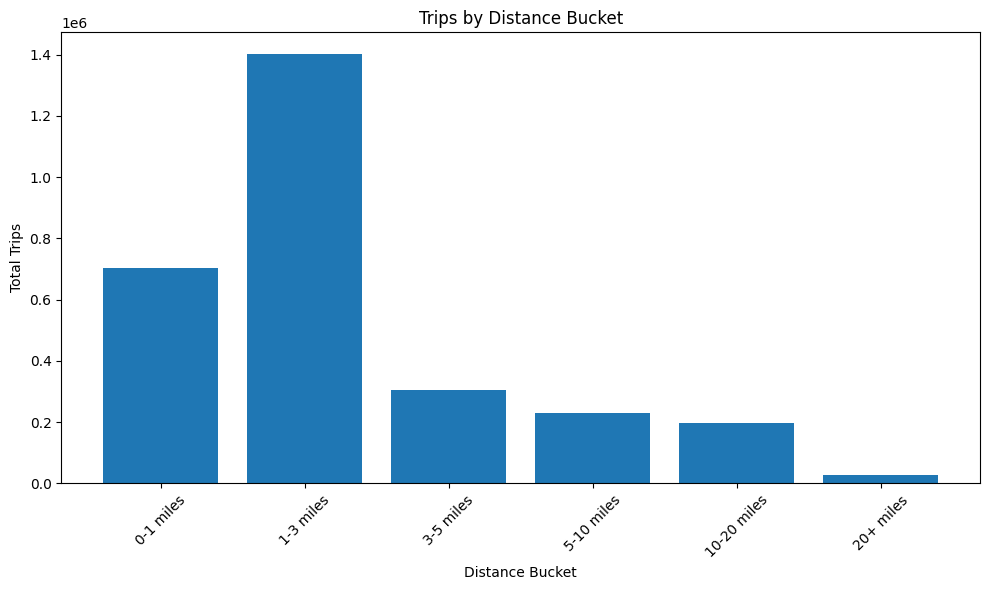

In [26]:
distance_bucket_summary.to_csv(processed_data_dir / "distance_bucket_summary.csv", index=False)

plt.figure(figsize=(10, 6))
plt.bar(distance_bucket_summary["distance_bucket"].astype(str), distance_bucket_summary["total_trips"])
plt.title("Trips by Distance Bucket")
plt.xlabel("Distance Bucket")
plt.ylabel("Total Trips")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(figures_dir / "distance_bucket_trips.png", dpi=300)
plt.show()

## Distance vs Revenue Scatter

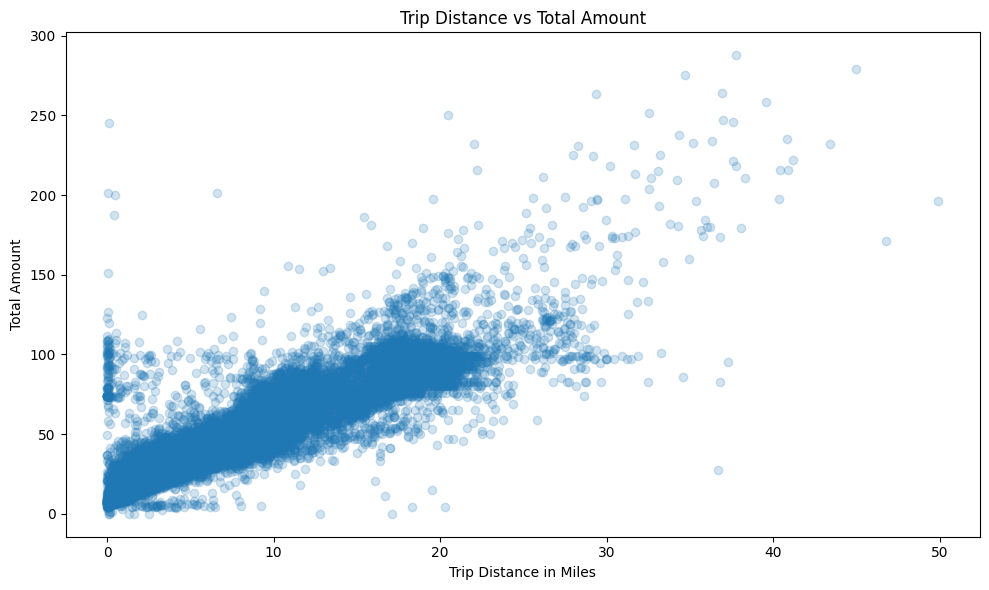

In [27]:
scatter_sample_size = min(100_000, len(taxi_trips))

scatter_sample = taxi_trips.sample(
    n=scatter_sample_size,
    random_state=42
)

scatter_sample = scatter_sample[
    (scatter_sample["trip_distance"] <= 50)
    & (scatter_sample["total_amount"] <= 300)
]

plt.figure(figsize=(10, 6))
plt.scatter(scatter_sample["trip_distance"], scatter_sample["total_amount"], alpha=0.2)
plt.title("Trip Distance vs Total Amount")
plt.xlabel("Trip Distance in Miles")
plt.ylabel("Total Amount")
plt.tight_layout()
plt.savefig(figures_dir / "distance_vs_total_amount.png", dpi=300)
plt.show()

## Correlation Preview

In [28]:
correlation_columns = [
    "trip_distance",
    "trip_duration_minutes",
    "fare_amount",
    "tip_amount",
    "total_amount",
    "revenue_per_mile",
    "fare_per_minute",
    "tip_percentage",
]

correlation_matrix = taxi_trips[correlation_columns].replace([np.inf, -np.inf], np.nan).corr()

correlation_matrix

,trip_distance,trip_duration_minutes,fare_amount,tip_amount,total_amount,revenue_per_mile,fare_per_minute,tip_percentage
trip_distance,1.00,0.02,0.02,0.01,0.02,-0.00,-0.00,-0.00
trip_duration_minutes,0.02,1.00,0.81,0.49,0.79,-0.05,-0.03,-0.00
fare_amount,0.02,0.81,1.00,0.60,0.98,0.07,0.09,-0.00
tip_amount,0.01,0.49,0.60,1.00,0.73,0.02,0.04,0.03
total_amount,0.02,0.79,0.98,0.73,1.00,0.05,0.08,0.00
revenue_per_mile,-0.00,-0.05,0.07,0.02,0.05,1.00,0.53,0.00
fare_per_minute,-0.00,-0.03,0.09,0.04,0.08,0.53,1.00,-0.00
tip_percentage,-0.00,-0.00,-0.00,0.03,0.00,0.00,-0.00,1.00


In [29]:
correlation_matrix.to_csv(processed_data_dir / "eda_correlation_matrix.csv")
print("EDA correlation matrix saved.")

EDA correlation matrix saved.


## EDA Findings Export

In [30]:
peak_hour_row = hourly_demand_summary.sort_values("total_trips", ascending=False).iloc[0]
top_pickup_borough_row = pickup_borough_summary.sort_values("total_trips", ascending=False).iloc[0]
top_dropoff_borough_row = dropoff_borough_summary.sort_values("total_trips", ascending=False).iloc[0]
top_pickup_zone_row = top_pickup_zones.sort_values("total_trips", ascending=False).iloc[0]
top_payment_row = payment_type_summary.sort_values("total_trips", ascending=False).iloc[0]

eda_findings_markdown = f"""# Initial EDA Findings

## KPI Summary

- Total trips analyzed: {total_trips:,.0f}
- Total revenue: ${total_revenue:,.2f}
- Average total amount per trip: ${average_total_amount:,.2f}
- Average fare amount: ${average_fare_amount:,.2f}
- Average trip distance: {average_trip_distance:,.2f} miles
- Average trip duration: {average_trip_duration:,.2f} minutes
- Average revenue per mile: ${average_revenue_per_mile:,.2f}
- Average tip percentage: {average_tip_percentage:,.2f}%
- Credit card payment share: {credit_card_share:,.2f}%

## Demand Findings

- Peak pickup hour by trip volume: {int(peak_hour_row["pickup_hour"])}:00
- Top pickup borough by trip volume: {top_pickup_borough_row["pickup_borough"]}
- Top drop-off borough by trip volume: {top_dropoff_borough_row["dropoff_borough"]}
- Top pickup zone by trip volume: {top_pickup_zone_row["pickup_zone"]}

## Payment Findings

- Most common payment type: {top_payment_row["payment_type_label"]}
- Trip share of most common payment type: {top_payment_row["trip_share_percentage"]:,.2f}%

## Notes

These are initial EDA findings. Final insights and recommendations will be refined after statistical analysis and Tableau dashboard development.
"""

with open(reports_dir / "eda_initial_findings.md", "w", encoding="utf-8") as file:
    file.write(eda_findings_markdown)

print("Initial EDA findings saved to reports/eda_initial_findings.md")

Initial EDA findings saved to reports/eda_initial_findings.md


## Done

EDA complete. Outputs saved to `data/processed/` and `reports/`.